# Introduction

## Car Insurance Fraud Detection – Exploratory Data Analysis

### Objective
The objective of this project is to build an end-to-end machine learning pipeline for detecting fraudulent car insurance claims. 
The dataset represents real-world insurance data, which is naturally imbalanced, making it suitable for studying preprocessing, 
feature selection, clustering, ensemble learning, and imbalance handling techniques.

Before building any machine learning models, it is essential to understand the dataset, its structure, feature types, 
and potential data quality issues. This section focuses on Exploratory Data Analysis (EDA) to guide informed preprocessing 
and modeling decisions.

<div style="text-align:center;">
  <img src="ml_pipeline_flow_FIXED.png" 
       alt="ML pipeline flow" style="max-width:50%; height:auto;"/>
</div>


# Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
df = pd.read_csv("carclaims.csv")

# Display first few rows
df.head()


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


## Dataset Overview

In this section, we examine the size, structure, and basic properties of the dataset. 
Understanding the number of records, features, and data types helps identify potential preprocessing requirements such as 
encoding, scaling, or feature selection.


In [2]:
# Dataset shape
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Data types
df.info()


Number of rows: 15420
Number of columns: 33
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  obje

## Feature Description

The dataset contains 33 attributes describing car insurance claims. These features can be grouped as follows:

### Target Variable
- **FraudFound**: Indicates whether a claim is fraudulent (`Yes`) or not (`No`).

### Numerical Features
Examples include:
- Age
- Year
- Deductible
- DriverRating
- WeekOfMonth, WeekOfMonthClaimed

### Categorical Features
Examples include:
- PolicyType, VehicleCategory, VehiclePrice
- AccidentArea, Fault, Sex, MaritalStatus
- PastNumberOfClaims, PoliceReportFiled, WitnessPresent

### Identifier-like Features
- PolicyNumber
- RepNumber

These identifier-like features do not represent meaningful claim characteristics and will be evaluated later for removal.


## Target Variable Distribution

Fraud detection problems are typically characterized by class imbalance. 
Therefore, we analyze the distribution of the target variable to understand whether accuracy alone will be a reliable evaluation metric.


In [3]:
# Target distribution
fraud_counts = df["FraudFound"].value_counts()
fraud_percent = df["FraudFound"].value_counts(normalize=True) * 100

fraud_summary = pd.DataFrame({
    "Count": fraud_counts,
    "Percentage": fraud_percent.round(2)
})

fraud_summary


,Count,Percentage
FraudFound,,
No,14497,94.01
Yes,923,5.99


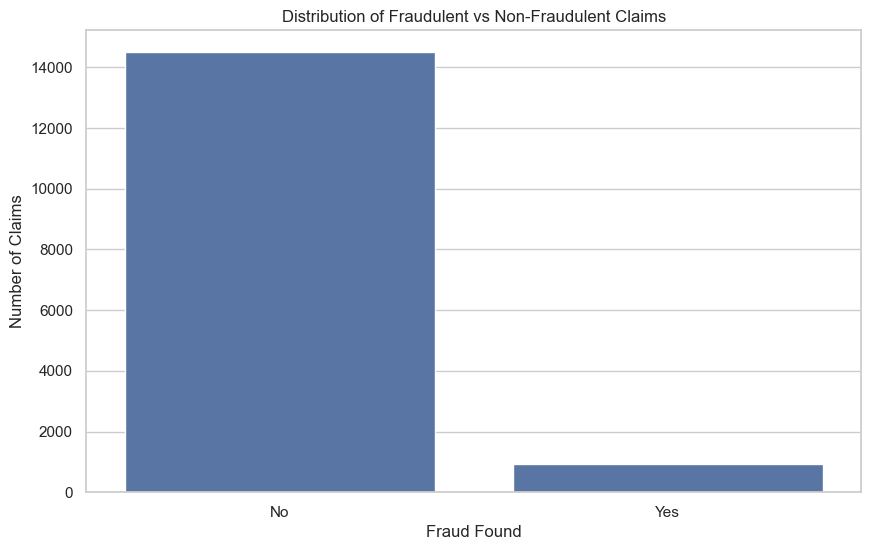

In [4]:
# Bar plot of target variable
sns.countplot(x="FraudFound", data=df)
plt.title("Distribution of Fraudulent vs Non-Fraudulent Claims")
plt.xlabel("Fraud Found")
plt.ylabel("Number of Claims")
plt.show()


### Observation
The dataset is highly imbalanced, with fraudulent claims representing a small fraction of the total observations.
This confirms that accuracy alone may be misleading and highlights the need for imbalance handling techniques such as SMOTE 
and cost-sensitive learning in later stages.


## Numerical Feature Distributions

Analyzing numerical features helps detect skewness, invalid values, and potential outliers. 
This is particularly important for distance-based models such as KNN and SVM, which are sensitive to scale and extreme values.


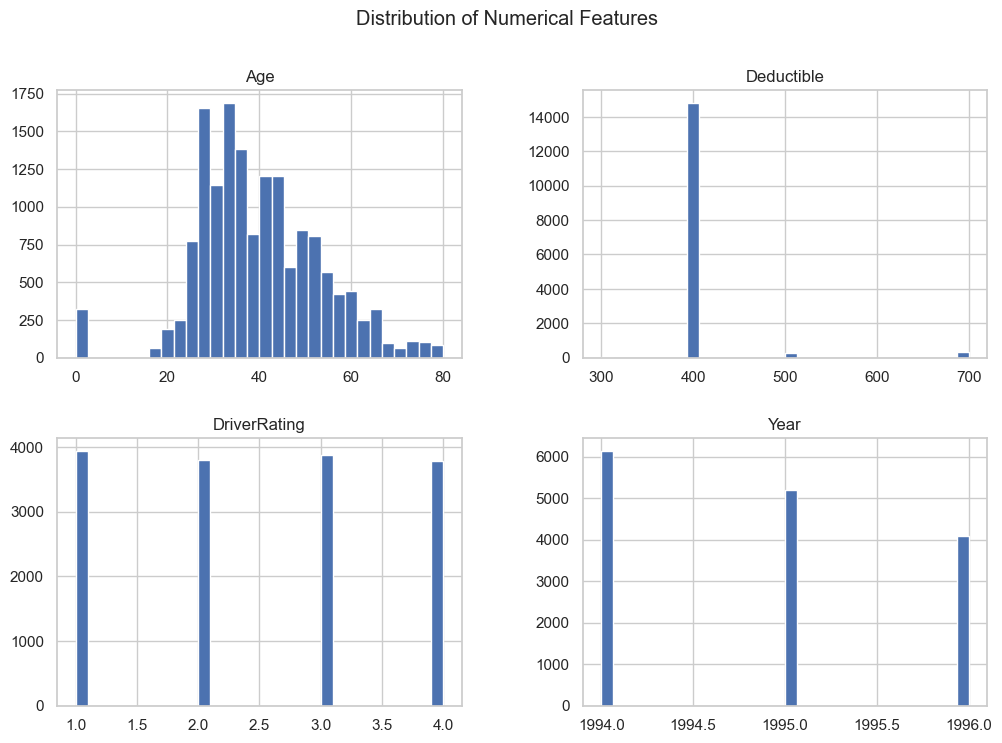

In [5]:
numerical_features = ["Age", "Deductible", "DriverRating", "Year"]

df[numerical_features].hist(bins=30, figsize=(12, 8))
plt.suptitle("Distribution of Numerical Features")
plt.show()


## Data Quality Check: Age Feature

While inspecting numerical distributions, we specifically examine the `Age` feature to identify invalid or suspicious values.


In [6]:
# Check invalid age values
df[df["Age"] == 0][["Age", "AgeOfPolicyHolder"]].head()

,Age,AgeOfPolicyHolder
7,0,16 to 17
13,0,16 to 17
28,0,16 to 17
31,0,16 to 17
58,0,16 to 17


### Observation
The `Age` feature contains zero values, which are not realistic ages.
These entries correspond to policy holders aged "16 to 17", indicating that zero is used as a placeholder.
This issue will be handled explicitly during the data cleaning stage.


## Outlier Detection


Outlier rows: 1116


,WeekOfMonth,WeekOfMonthClaimed,Age,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,1116.000000,1116.000000,1116.000000,1116.000000,1116.000000,1116.000000,1116.000000,1116.000000
mean,2.728495,2.724014,37.830645,7590.326165,8.590502,506.451613,2.510753,1994.847670
std,1.277165,1.232954,28.323769,4551.705719,4.657783,127.245916,1.107201,0.801402
min,1.000000,1.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
1%,1.000000,1.000000,0.000000,105.550000,1.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,40.000000,7631.000000,9.000000,500.000000,3.000000,1995.000000
99%,5.000000,5.000000,80.000000,15282.650000,16.000000,700.000000,4.000000,1996.000000
max,5.000000,5.000000,80.000000,15408.000000,16.000000,700.000000,4.000000,1996.000000


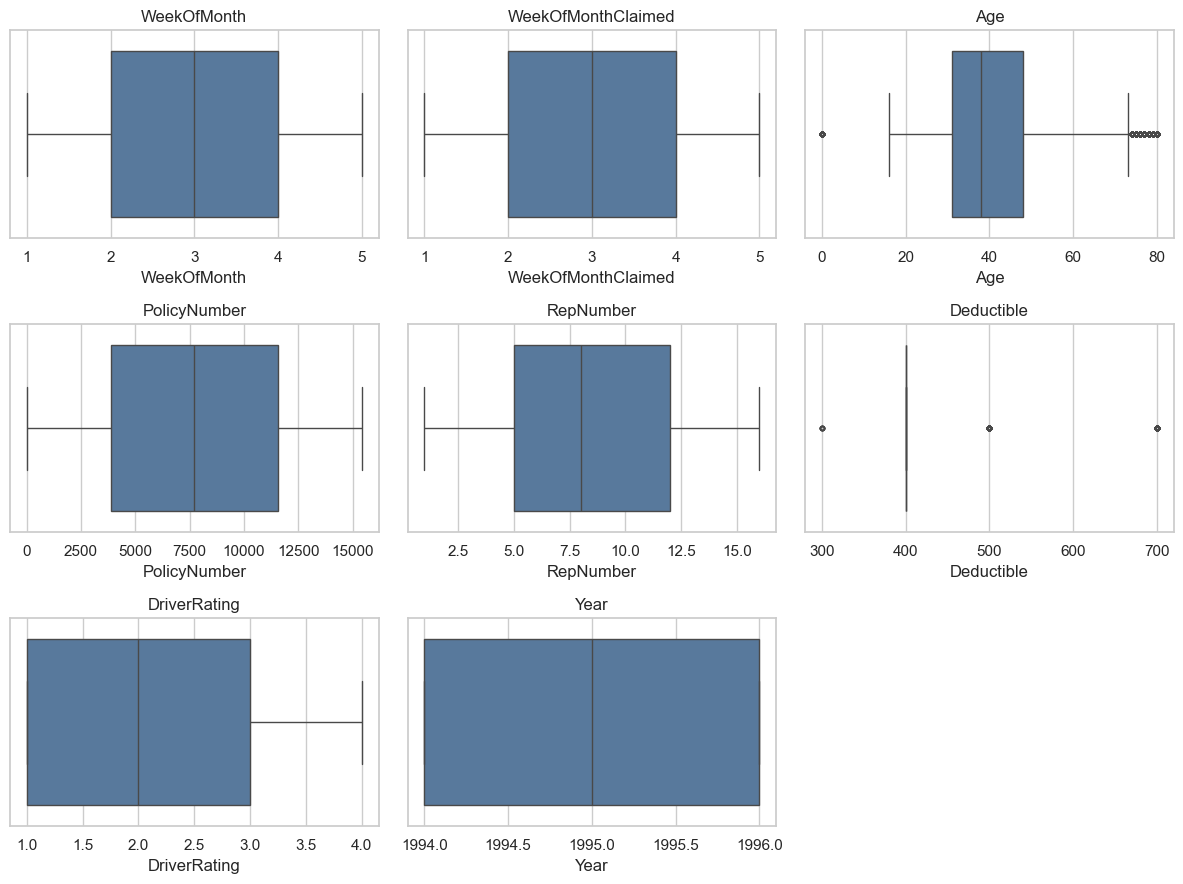

In [7]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("carclaims.csv")

num_cols = df.select_dtypes(include=np.number).columns
outlier_masks = {}

for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_masks[col] = (df[col] < lower) | (df[col] > upper)

outlier_any = pd.DataFrame(outlier_masks).any(axis=1)
outliers = df[outlier_any]
print(f"Outlier rows: {outliers.shape[0]}")
display(outliers[num_cols].describe(percentiles=[0.01, 0.99]))

ncols = 3
nrows = math.ceil(len(num_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax, color="#4c78a8", fliersize=3)
    ax.set_title(col)

for ax in axes[len(num_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()


## Summary of EDA Findings

- The dataset is highly imbalanced, with fraudulent claims being a minority class.
- Numerical features show skewness and the presence of outliers.
- The `Age` feature contains invalid values that require correction.
- Many features are categorical, which necessitates careful encoding strategies.
- Identifier-like features are present and will be evaluated for removal.

These insights will guide preprocessing, feature selection, clustering, and modeling decisions in the subsequent stages.


## Data Cleaning and Preparation

Before building any machine learning models, it is necessary to clean the dataset to address 
data quality issues that may negatively affect model performance or lead to misleading results.

This step focuses on:
- Removing non-informative identifier features
- Correcting invalid values
- Ensuring consistency between related attributes

Each cleaning decision is justified to maintain transparency and reproducibility.


## Removing Identifier-like Features

The dataset contains the following identifier-related attributes:
- **PolicyNumber**
- **RepNumber**

These features uniquely identify records but do not provide meaningful information about 
claim behavior or fraud risk. Including such identifiers may cause models to memorize specific 
records rather than learn generalizable fraud patterns.

Therefore, these columns are removed from the dataset.


In [8]:
# Drop identifier-like columns
df.drop(columns=["PolicyNumber", "RepNumber"], inplace=True)

df.shape


(15420, 31)

## Removal of Low-Variance Feature (Deductible)

Analysis of the `Deductible` feature revealed that more than 96% of observations share the same value (400), 
resulting in extremely low variance. Features with near-zero variance provide minimal discriminative power 
and do not contribute meaningfully to classification performance. Therefore, this feature was removed 
during preprocessing.


In [9]:
df["Deductible"].value_counts(normalize=True).head()


Deductible
400    0.962257
700    0.020169
500    0.017056
300    0.000519
Name: proportion, dtype: float64

In [10]:
# Drop near-zero variance feature
df.drop(columns=["Deductible"], inplace=True)


## Handling Invalid Values in the Age Feature

During exploratory analysis, we observed that the `Age` feature contains zero values, 
which are not realistic ages. These zero values correspond to policy holders categorized 
as "16 to 17" in the `AgeOfPolicyHolder` attribute.

To correct this inconsistency, we replace `Age = 0` with a representative age value 
that aligns with the corresponding age group.


In [11]:
# Number of invalid age values before fixing
invalid_age_count = (df["Age"] == 0).sum()
invalid_age_count


320

In [12]:
# Replace Age == 0 with 16 (consistent with "16 to 17" age group)
df.loc[df["Age"] == 0, "Age"] = 16
# Verify fix
(df["Age"] == 0).sum()


0

## Missing Values Check

We verify whether the dataset contains missing (NaN) values, as these would require imputation 
before modeling.


In [13]:
# Check for missing values
df.isnull().sum()


Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
DriverRating            0
Days:Policy-Accident    0
Days:Policy-Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange-Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
FraudFound              0
dtype: int64

## Duplicate Records Check

Duplicate observations may bias model training by over-representing certain claim patterns.
We therefore check for duplicated rows in the dataset.


In [14]:
# Check for duplicate rows
df.duplicated().sum()


0

In [15]:
## Dataset Status After Cleaning

df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


## Outliers (Visualization + Detection + Removal)

We handle outliers once during preprocessing.  
Outliers can distort distance-based models (KNN, SVM), so we:
1) visualize numeric features using boxplots  
2) detect and remove outliers using Isolation Forest (lab method)  
3) apply an IQR rule specifically to `Age` to remove any remaining extreme values flagged by boxplots.


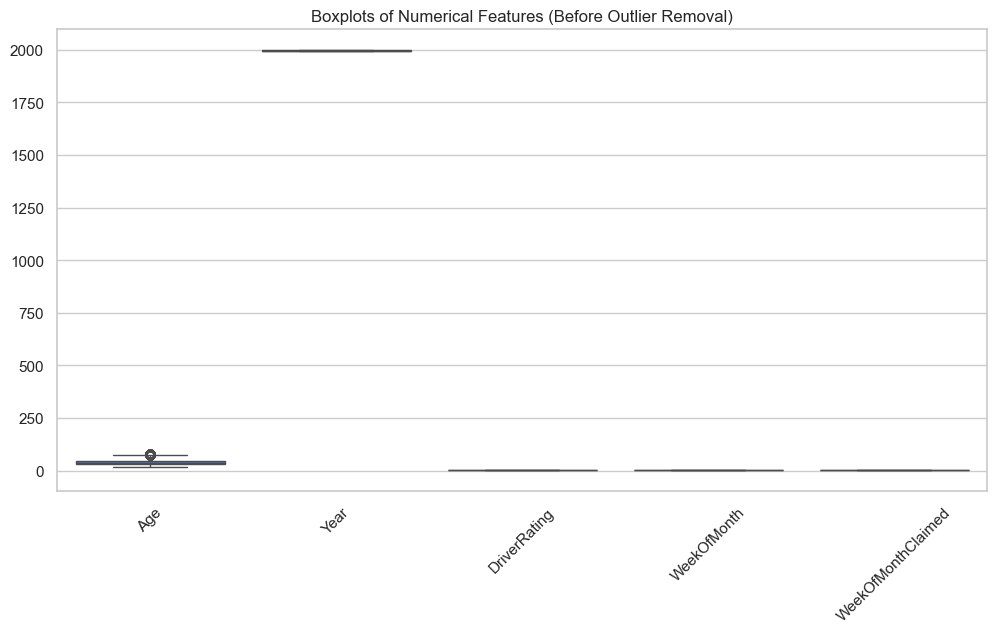

Removed by IsolationForest: 307
Shape after IsolationForest: (15113, 30)
Removed by Age IQR rule: 167
Final shape after outlier removal: (14946, 30)


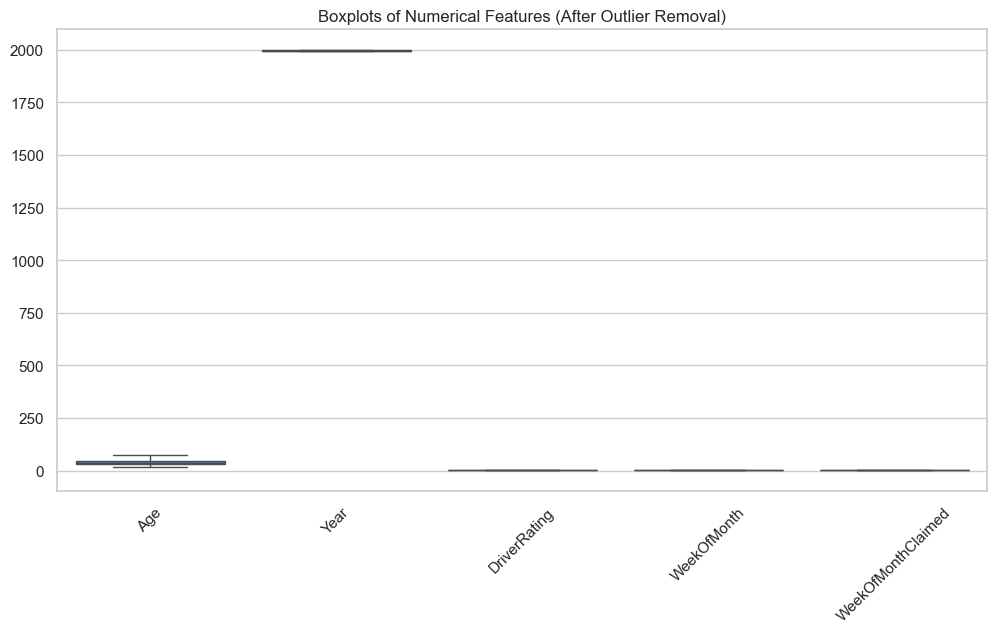

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# -----------------------------
# 1) Visualize outliers (boxplots)
# -----------------------------
num_cols = ["Age", "Year", "DriverRating", "WeekOfMonth", "WeekOfMonthClaimed"]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols])
plt.title("Boxplots of Numerical Features (Before Outlier Removal)")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 2) Detect & remove outliers (Isolation Forest)
#    - uses numeric features only (stable for this dataset)
# -----------------------------
X_num = df[num_cols].copy()

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

iso = IsolationForest(
    n_estimators=300,
    contamination=0.02,   # remove ~2% as outliers
    random_state=42
)

labels = iso.fit_predict(X_num_scaled)   # -1 outlier, 1 inlier
removed_iso = int(np.sum(labels == -1))

df = df.loc[labels != -1].reset_index(drop=True)

print(f"Removed by IsolationForest: {removed_iso}")
print("Shape after IsolationForest:", df.shape)

# -----------------------------
# 3) Age-specific IQR removal (boxplot rule)
#    - ensures Age doesn't keep extreme boxplot outliers
# -----------------------------
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before = df.shape[0]
df = df[(df["Age"] >= lower) & (df["Age"] <= upper)].reset_index(drop=True)
removed_age = before - df.shape[0]

print(f"Removed by Age IQR rule: {removed_age}")
print("Final shape after outlier removal:", df.shape)

# -----------------------------
# 4) Visualize after removal (sanity check)
# -----------------------------
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols])
plt.title("Boxplots of Numerical Features (After Outlier Removal)")
plt.xticks(rotation=45)
plt.show()


#### as you can see the min is 16 years and the max is 73 years which is right 100%

In [17]:
print("Final dataset shape:", df.shape)
df["Age"].describe()

Final dataset shape: (14946, 30)


count    14946.000000
mean        39.552924
std         11.746898
min         16.000000
25%         30.000000
50%         38.000000
75%         48.000000
max         73.000000
Name: Age, dtype: float64

## Split features and target

We separate the target (`FraudFound`) and perform a stratified train/test split to preserve the fraud ratio in both sets.


In [18]:
from sklearn.model_selection import train_test_split

# Target to binary
y = df["FraudFound"].map({"No": 0, "Yes": 1})
X = df.drop(columns=["FraudFound"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train.value_counts(normalize=True).round(4), y_test.value_counts(normalize=True).round(4)


(FraudFound
 0    0.9399
 1    0.0601
 Name: proportion, dtype: float64,
 FraudFound
 0    0.9401
 1    0.0599
 Name: proportion, dtype: float64)

## MLflow setup

In [70]:
!pip install mlflow

  Using cached importlib_metadata-8.7.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached zipp-3.23.0-py3-none-any.whl.metadata (3.6 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached rsa-4.9.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached pyasn1-0.6.1-py3-none-any.whl.metadata (8.4 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.9 MB 289.0 kB/s eta 0:00:30
   -- ---------------------------------

In [71]:
import os
import mlflow
import mlflow.sklearn

# store runs locally inside your project folder
mlruns_path = os.path.abspath("mlruns")
os.makedirs(mlruns_path, exist_ok=True)

mlflow.set_tracking_uri(f"file:{mlruns_path}")
mlflow.set_experiment("Fraud_Detection")

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", mlflow.get_experiment_by_name("Fraud_Detection").name)


c:\Users\bidog\anaconda3\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:177: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance.
  return FileStore(store_uri, store_uri)
2025/12/20 21:01:46 INFO mlflow.tracking.fluent: Experiment with name 'Fraud_Detection' does not exist. Creating a new experiment.


Tracking URI: file:c:\Users\bidog\Desktop\ML_2\mlruns
Experiment: Fraud_Detection


## Feature types

We separate features into numeric, nominal (one-hot), and ordinal (ordered categories). This determines the correct encoding strategy.


In [19]:
numeric_features = ["Age", "Year", "DriverRating", "WeekOfMonth", "WeekOfMonthClaimed"]

nominal_features = [
    "Month", "DayOfWeek", "MonthClaimed", "DayOfWeekClaimed",
    "Make", "AccidentArea", "Sex", "MaritalStatus", "Fault",
    "PolicyType", "VehicleCategory", "AgentType", "BasePolicy",
    "PoliceReportFiled", "WitnessPresent"
]

ordinal_features = [
    "VehiclePrice", "Days:Policy-Accident", "Days:Policy-Claim",
    "PastNumberOfClaims", "AgeOfVehicle", "AgeOfPolicyHolder",
    "NumberOfSuppliments", "AddressChange-Claim", "NumberOfCars"
]




## Ordinal category order

Ordinal encoding must follow the true order of each feature’s levels.


In [20]:
vehicle_price_order = ["less than 20000", "20000 to 29000", "30000 to 39000", "40000 to 59000", "60000 to 69000", "more than 69000"]
days_policy_accident_order = ["none", "1 to 7", "8 to 15", "15 to 30", "more than 30"]
days_policy_claim_order = ["none", "1 to 7", "8 to 15", "15 to 30", "more than 30"]
past_claims_order = ["none", "1", "2 to 4", "more than 4"]
age_vehicle_order = ["new", "2 years", "3 years", "4 years", "5 years", "6 years", "7 years", "more than 7"]
age_policyholder_order = ["16 to 17", "18 to 20", "21 to 25", "26 to 30", "31 to 35", "36 to 40", "41 to 50", "51 to 65", "over 65"]
num_supp_order = ["none", "1", "2", "3", "more than 3"]
addr_change_order = ["no change", "under 6 months", "6 months to 1 year", "1 year to 2 years", "2 to 3 years", "3 to 4 years", "4 to 5 years", "more than 5 years"]
num_cars_order = ["1 vehicle", "2 vehicles", "3 to 4", "5 to 8", "more than 8"]

ordinal_categories = [
    vehicle_price_order,
    days_policy_accident_order,
    days_policy_claim_order,
    past_claims_order,
    age_vehicle_order,
    age_policyholder_order,
    num_supp_order,
    addr_change_order,
    num_cars_order
]


## Pipeline start

## Preprocessing transformer

- Numeric → standard scaling  
- Nominal → one-hot encoding  
- Ordinal → ordinal encoding (ordered categories)


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

ordinal_transformer = Pipeline(steps=[
    ("ordinal", OrdinalEncoder(categories=ordinal_categories, handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("nom", nominal_transformer, nominal_features),
        ("ord", ordinal_transformer, ordinal_features),
    ],
    remainder="drop"
)


## Preprocessing sanity check

We transform only the training set to verify the output is numeric and ready for modeling.


In [22]:
Xt = preprocess.fit_transform(X_train, y_train)
Xt.shape

(11956, 102)

## Baseline Models (Imbalanced Data)

In this step, we train baseline classification models using the original imbalanced dataset.
No imbalance handling techniques (such as SMOTE or class weighting) are applied at this stage.

These baseline results will be used later to evaluate the impact of imbalance handling
and other enhancements.


### Models to Evaluate (Baseline)

We evaluate three baseline classifiers from different families:
- **KNN** (distance-based)
- **SVM (RBF)** (kernel-based)
- **Decision Tree** (tree-based)

At this stage, we do **not** apply any imbalance handling (no SMOTE / no class weights).  
These results will be used later as a reference to measure performance improvements.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# KNN baseline pipeline
knn_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier())
])

# SVM baseline pipeline (probability=True needed for ROC-AUC using predict_proba)
svm_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", probability=True, random_state=42))
])

# Decision Tree pipeline (will be tuned)
dt_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Decision Tree hyperparameter search space
dt_param_grid = {
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 10, 30],
    "model__min_samples_leaf": [1, 5, 10]
}

# Tune using F1 because the dataset is imbalanced
dt_grid = GridSearchCV(
    dt_pipe,
    param_grid=dt_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)


### Training

Each model is trained on the training set using the same preprocessing pipeline.  
The Decision Tree is tuned using cross-validation, then we keep the best configuration.


In [81]:
knn_results = log_run("KNN (Baseline)", knn_pipe, X_train, y_train, X_test, y_test,
                      stage="baseline")

svm_results = log_run("SVM (Baseline)", svm_pipe, X_train, y_train, X_test, y_test,
                      stage="baseline")


# 3) Decision Tree tuned baseline (GridSearch) - needs its own MLflow block
import mlflow
import mlflow.sklearn

with mlflow.start_run(run_name="Decision Tree (Tuned Baseline)"):
    mlflow.set_tag("stage", "baseline")

    dt_grid.fit(X_train, y_train)
    best_dt = dt_grid.best_estimator_

    # log best hyperparams + best CV score
    mlflow.log_params(dt_grid.best_params_)
    mlflow.log_metric("cv_best_f1", dt_grid.best_score_)

    dt_results = evaluate_model("Decision Tree (Tuned Baseline)", best_dt, X_test, y_test)

    mlflow.log_metrics({
        "accuracy": dt_results["Accuracy"],
        "precision": dt_results["Precision"],
        "recall": dt_results["Recall"],
        "f1": dt_results["F1"],
        "roc_auc": dt_results["ROC_AUC"],
    })

    mlflow.sklearn.log_model(best_dt, "model")

print("Best Decision Tree parameters:", dt_grid.best_params_)


2025/12/20 21:48:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/20 21:48:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/20 21:48:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Best Decision Tree parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}


### Evaluation (Baseline Comparison)

We evaluate using metrics that are meaningful under class imbalance:
- **Precision** (how many predicted frauds are truly fraud)
- **Recall** (how many actual frauds we catch)
- **F1-score** (balance of precision & recall)
- **ROC-AUC** (ranking ability across thresholds)

Results are summarized in a single comparison table.


In [78]:
def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1": f1_score(y_eval, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_eval, y_prob)
    }


import mlflow
import mlflow.sklearn

def log_run(run_name, model, X_train, y_train, X_test, y_test, stage, extra_params=None):
    """
    One run = one trained model.
    TA rule satisfied: fit + logging inside mlflow.start_run.
    """
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("stage", stage)

        # train
        model.fit(X_train, y_train)

        # evaluate (your function)
        res = evaluate_model(run_name, model, X_test, y_test)

        # params: log only estimator params (avoid huge preprocess dict)
        if hasattr(model, "named_steps") and "model" in model.named_steps:
            params = model.named_steps["model"].get_params()
        else:
            params = model.get_params()

        if extra_params:
            params.update(extra_params)

        mlflow.log_params(params)

        mlflow.log_metrics({
            "accuracy": res["Accuracy"],
            "precision": res["Precision"],
            "recall": res["Recall"],
            "f1": res["F1"],
            "roc_auc": res["ROC_AUC"]
        })

        mlflow.sklearn.log_model(model, "model")

    return res




results = [
    evaluate_model("KNN (Baseline)", knn_pipe, X_test, y_test),
    evaluate_model("SVM (Baseline)", svm_pipe, X_test, y_test),
    evaluate_model("Decision Tree (Tuned Baseline)", best_dt, X_test, y_test)
]

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
results_df



,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Decision Tree (Tuned Baseline),0.897659,0.174359,0.189944,0.181818,0.566335
0,KNN (Baseline),0.935786,0.217391,0.027933,0.049505,0.634040
1,SVM (Baseline),0.940134,0.000000,0.000000,0.000000,0.798177


### Confusion Matrices

Confusion matrices help visualize the number of:
- True frauds detected (TP)
- Frauds missed (FN)
- False alarms (FP)
- Correct non-fraud predictions (TN)


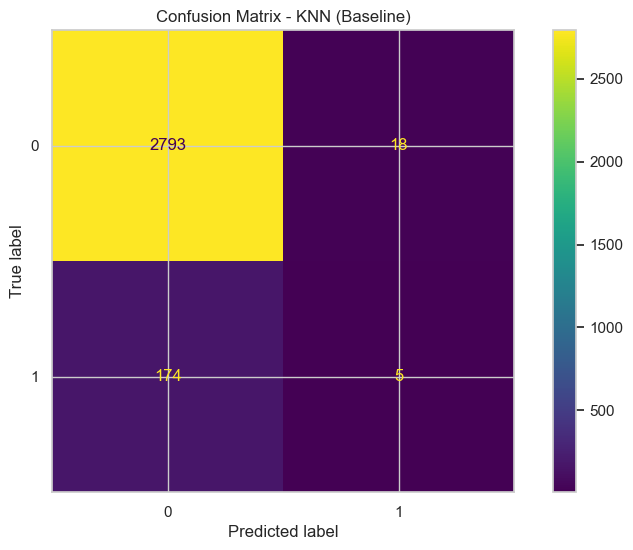

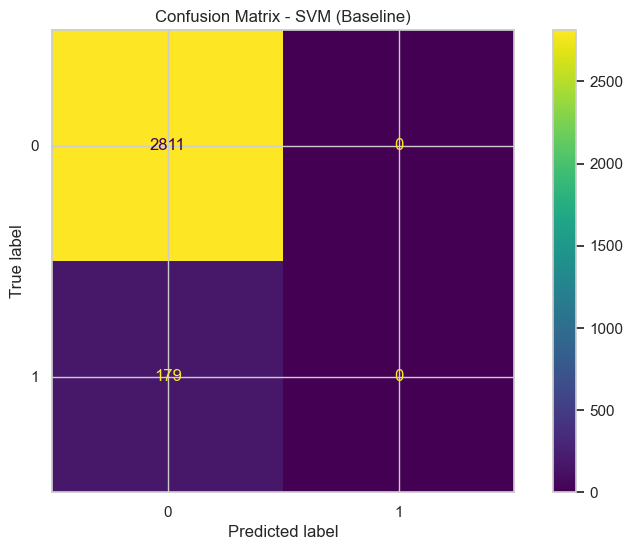

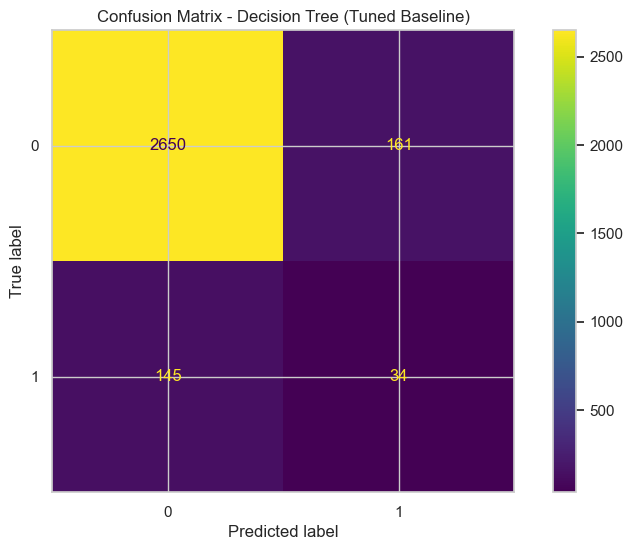

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models_fitted = {
    "KNN (Baseline)": knn_pipe,
    "SVM (Baseline)": svm_pipe,
    "Decision Tree (Tuned Baseline)": best_dt
}

for name, model in models_fitted.items():
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


## Confusion Matrix Analysis (Baseline Models)

This section analyzes the confusion matrices of the baseline models trained on the original imbalanced dataset.
The goal is to understand how each model behaves when predicting the minority (fraud) class and why accuracy
alone is not sufficient for evaluation.

In all matrices:
- Class **0** represents *Non-Fraud*
- Class **1** represents *Fraud*


### KNN (Baseline) – Confusion Matrix Interpretation

The KNN baseline model produces the following results:

- **True Negatives (TN): 2793**  
  Non-fraudulent claims correctly classified as non-fraud.

- **False Positives (FP): 18**  
  Non-fraudulent claims incorrectly flagged as fraud.

- **False Negatives (FN): 174**  
  Fraudulent claims incorrectly classified as non-fraud.

- **True Positives (TP): 5**  
  Fraudulent claims correctly detected.

Although KNN achieves high overall accuracy, it detects only a very small number of fraudulent claims.
The recall for the fraud class is extremely low, indicating that the model misses most fraud cases.
This behavior is expected because KNN relies on majority voting and is biased toward the dominant class
in highly imbalanced datasets.


### SVM (Baseline) – Confusion Matrix Interpretation

The SVM baseline model shows the following behavior:

- **True Negatives (TN): 2811**  
  All non-fraudulent claims are correctly classified.

- **False Positives (FP): 0**  
  No non-fraudulent claims are misclassified as fraud.

- **False Negatives (FN): 179**  
  All fraudulent claims are misclassified as non-fraud.

- **True Positives (TP): 0**  
  No fraudulent claims are detected.

The SVM model completely fails to identify the minority class and predicts all samples as non-fraud.
This results in perfect precision for the non-fraud class but zero recall for fraud.
Such behavior highlights the strong bias of margin-based classifiers toward the majority class
when trained on imbalanced data without class weighting or resampling.


### Decision Tree (Tuned Baseline) – Confusion Matrix Interpretation

The tuned Decision Tree model produces the following results:

- **True Negatives (TN): 2650**  
  Non-fraudulent claims correctly classified.

- **False Positives (FP): 161**  
  Non-fraudulent claims incorrectly flagged as fraud.

- **False Negatives (FN): 145**  
  Fraudulent claims missed by the model.

- **True Positives (TP): 34**  
  Fraudulent claims correctly detected.

Compared to KNN and SVM, the Decision Tree identifies more fraudulent claims and achieves higher recall
for the minority class. However, this improvement comes at the cost of an increased number of false positives.
This trade-off is typical for tree-based models, which are more flexible and can adapt better to minority patterns
even without explicit imbalance handling.


### ROC Curves

ROC curves compare how well models separate classes across different thresholds.  
This is especially useful when the dataset is imbalanced.


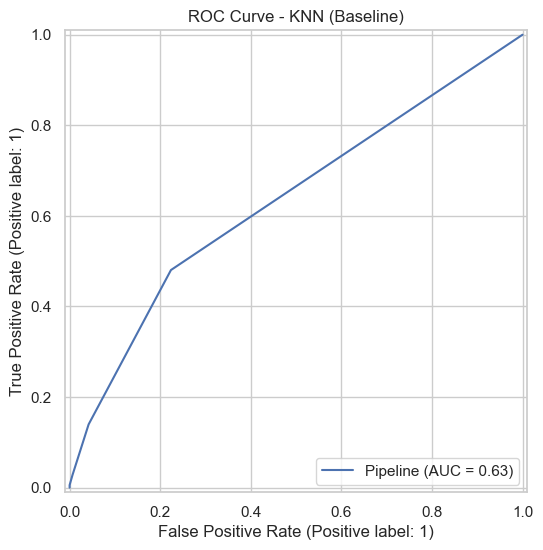

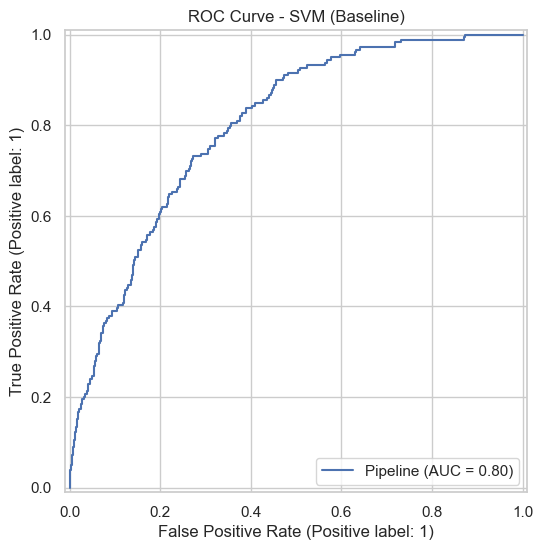

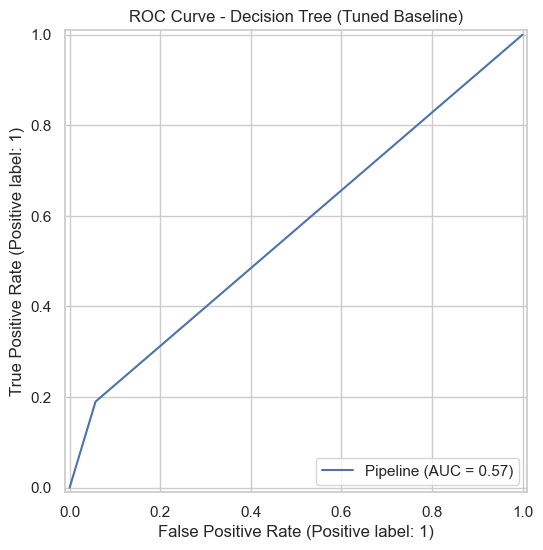

In [27]:
from sklearn.metrics import RocCurveDisplay

for name, model in models_fitted.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"ROC Curve - {name}")
    plt.show()


## ROC Curve Analysis (Baseline Models)

ROC curves illustrate the trade-off between the True Positive Rate (Recall) and the False Positive Rate
across different classification thresholds. The Area Under the Curve (AUC) summarizes the model’s
ability to distinguish between fraud and non-fraud cases.


### KNN (Baseline) – ROC Curve Interpretation

The KNN baseline model achieves an **AUC of approximately 0.63**, indicating weak discriminatory power.
The ROC curve lies only slightly above the diagonal line, showing that the model performs only marginally
better than random guessing. This aligns with the confusion matrix results, where KNN detects very few
fraud cases and suffers from extremely low recall.


### SVM (Baseline) – ROC Curve Interpretation

The SVM baseline model achieves a relatively high **AUC of approximately 0.80**, suggesting good
separation ability between classes. However, despite this high AUC, the confusion matrix shows that the
model predicts all samples as non-fraud at the default threshold. This highlights that a high ROC-AUC
does not guarantee good minority-class detection without proper threshold tuning or imbalance handling.


### Decision Tree (Tuned Baseline) – ROC Curve Interpretation

The tuned Decision Tree baseline model achieves an **AUC of approximately 0.57**, which is close to random
performance. The ROC curve remains near the diagonal, indicating limited ranking capability. This result
is consistent with the model’s moderate recall and relatively high false positive rate observed in the
confusion matrix.


########################################################################################################

## Feature Selection (Model-Specific)

In this step, feature selection is applied separately for each model.
Different models rely on different assumptions and learning mechanisms;
therefore, a single global feature selection method may not be optimal.

We evaluate whether model-specific feature selection improves performance
compared to the baseline models.
|

### Selected Feature Selection Methods

- **KNN & SVM**: Mutual Information (filters non-informative features)
- **Decision Tree**: Model-based selection using tree feature importance

Each model is evaluated before and after feature selection.


### KNN + Feature Selection

Mutual Information is used to retain features that have the strongest
dependency with the target variable. This is suitable for distance-based
models such as KNN, which are sensitive to noisy and irrelevant features.


In [28]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

knn_fs_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("feature_selection", SelectKBest(
        score_func=mutual_info_classif,
        k=30
    )),
    ("model", KNeighborsClassifier())
])

knn_fs_pipe.fit(X_train, y_train)


c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bid

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Year',
                                                   'DriverRating',
                                                   'WeekOfMonth',
                                                   'WeekOfMonthClaimed']),
                                                 ('nom',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Month', 'DayOfWeek',
                                                   'MonthClaimed',
                                                   'DayOfWeekClaimed', 'Make',
                                                   'AccidentArea', 'Sex',
                                                   'MaritalSta...
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['VehiclePrice',
                                                   'Days:Policy-Accident',
                                                   'Days:Policy-Claim',
                                                   'PastNumberOfClaims',
                                                   'AgeOfVehicle',
                                                   'AgeOfPolicyHolder',
                                                   'NumberOfSuppliments',
                                                   'AddressChange-Claim',
                                                   'NumberOfCars'])])),
                ('feature_selection',
                 SelectKBest(k=30,
                             score_func=<function mutual_info_classif at 0x000002493C3282C0>)),
                ('model', KNeighborsClassifier())])

### just training it again so we can see the logs inside the MLFLOW UI because when i run it in the previous cell the Pipeline figure didn't show up 

In [87]:
knn_fs_results = log_run("KNN + FS", knn_fs_pipe, X_train, y_train, X_test, y_test,
                         stage="feature_selection",
                         extra_params={"fs": "SelectKBest"})

c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bid

### SVM + Feature Selection

The same mutual information-based feature selection is applied to SVM.
Reducing the feature space can help SVM focus on the most discriminative
dimensions and improve generalization.


In [29]:
svm_fs_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("feature_selection", SelectKBest(
        score_func=mutual_info_classif,
        k=30
    )),
    ("model", SVC(kernel="rbf", probability=True, random_state=42))
])

svm_fs_pipe.fit(X_train, y_train)


c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bid

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Year',
                                                   'DriverRating',
                                                   'WeekOfMonth',
                                                   'WeekOfMonthClaimed']),
                                                 ('nom',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Month', 'DayOfWeek',
                                                   'MonthClaimed',
                                                   'DayOfWeekClaimed', 'Make',
                                                   'AccidentArea', 'Sex',
                                                   'MaritalSta...
                                                                                  unknown_value=-1))]),
                                                  ['VehiclePrice',
                                                   'Days:Policy-Accident',
                                                   'Days:Policy-Claim',
                                                   'PastNumberOfClaims',
                                                   'AgeOfVehicle',
                                                   'AgeOfPolicyHolder',
                                                   'NumberOfSuppliments',
                                                   'AddressChange-Claim',
                                                   'NumberOfCars'])])),
                ('feature_selection',
                 SelectKBest(k=30,
                             score_func=<function mutual_info_classif at 0x000002493C3282C0>)),
                ('model', SVC(probability=True, random_state=42))])

### just training it again so we can see the logs inside the MLFLOW UI because when i run it in the previous cell the Pipeline figure didn't show up 

In [88]:
svm_fs_results = log_run("SVM + FS", svm_fs_pipe, X_train, y_train, X_test, y_test,
                         stage="feature_selection",
                         extra_params={"fs": "SelectKBest"})

c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bid

### Decision Tree + Feature Selection

Tree-based models provide intrinsic feature importance scores.
We use a Random Forest-based selector to retain only the most informative
features before training the final Decision Tree model.


In [84]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

dt_fs_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("feature_selection", SelectFromModel(
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),
        threshold="median"
    )),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=best_dt.named_steps["model"].max_depth,
        min_samples_split=best_dt.named_steps["model"].min_samples_split,
        min_samples_leaf=best_dt.named_steps["model"].min_samples_leaf
    ))
])

dt_fs_pipe.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Year',
                                                   'DriverRating',
                                                   'WeekOfMonth',
                                                   'WeekOfMonthClaimed']),
                                                 ('nom',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Month', 'DayOfWeek',
                                                   'MonthClaimed',
                                                   'DayOfWeekClaimed', 'Make',
                                                   'AccidentArea', 'Sex',
                                                   'MaritalSta...
                                                  ['VehiclePrice',
                                                   'Days:Policy-Accident',
                                                   'Days:Policy-Claim',
                                                   'PastNumberOfClaims',
                                                   'AgeOfVehicle',
                                                   'AgeOfPolicyHolder',
                                                   'NumberOfSuppliments',
                                                   'AddressChange-Claim',
                                                   'NumberOfCars'])])),
                ('feature_selection',
                 SelectFromModel(estimator=RandomForestClassifier(n_estimators=200,
                                                                  random_state=42),
                                 threshold='median')),
                ('model', DecisionTreeClassifier(random_state=42))])

### just training it again so we can see the logs inside the MLFLOW UI because when i run it in the previous cell the Pipeline figure didn't show up 

In [86]:
dt_fs_results = log_run("Decision Tree + FS", dt_fs_pipe, X_train, y_train, X_test, y_test,
                        stage="feature_selection",
                        extra_params={"fs": "SelectKBest"})

2025/12/20 21:53:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


### Evaluation After Feature Selection

The performance of each model after feature selection is compared to
its baseline counterpart using the same evaluation metrics.


In [83]:
results_fs = [
    evaluate_model("KNN + FS", knn_fs_pipe, X_test, y_test),
    evaluate_model("SVM + FS", svm_fs_pipe, X_test, y_test),
    evaluate_model("Decision Tree + FS", dt_fs_pipe, X_test, y_test)
]

results_fs_df = pd.DataFrame(results_fs).sort_values(by="F1", ascending=False)
results_fs_df



,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Decision Tree + FS,0.889967,0.152778,0.184358,0.167089,0.559628
0,KNN + FS,0.932776,0.238095,0.055866,0.090498,0.706816
1,SVM + FS,0.940134,0.000000,0.000000,0.000000,0.747171


## Clustering for Data Preparation

In this step, clustering is used as a data preparation technique rather than
a standalone predictive model.

Following Lab 8, K-Means clustering is applied to the feature space to discover
latent structure in the data. The resulting cluster labels are added as an
additional feature to help supervised models capture hidden patterns.


### Choice of Clustering Algorithm

K-Means was selected because:
- It is an unsupervised algorithm covered in Lab 8
- It is simple and scalable
- It captures similarity structure in numerical feature space

The clustering process does not use the target labels, ensuring no data leakage.


In [32]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# Use numeric features only for clustering
X_num_train = X_train[numeric_features].copy()
X_num_test = X_test[numeric_features].copy()

# Scale numeric data (required for K-Means)
scaler_cluster = StandardScaler()
X_num_train_scaled = scaler_cluster.fit_transform(X_num_train)
X_num_test_scaled = scaler_cluster.transform(X_num_test)


In [33]:
# Choose number of clusters (small, interpretable value)
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit on training data only
train_clusters = kmeans.fit_predict(X_num_train_scaled)

# Predict clusters for test data
test_clusters = kmeans.predict(X_num_test_scaled)


In [34]:
# Add cluster feature to original datasets
X_train_clustered = X_train.copy()
X_test_clustered = X_test.copy()

X_train_clustered["Cluster"] = train_clusters
X_test_clustered["Cluster"] = test_clusters


In [35]:
# Update nominal features to include Cluster
nominal_features_cluster = nominal_features + ["Cluster"]

preprocess_cluster = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("nom", OneHotEncoder(handle_unknown="ignore"), nominal_features_cluster),
        ("ord", OrdinalEncoder(
            categories=ordinal_categories,
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ), ordinal_features),
    ]
)


### Model Training with Clustering Feature

We retrain selected models using the additional cluster feature and compare
their performance with previous results.


In [36]:
dt_cluster_pipe = Pipeline(steps=[
    ("preprocess", preprocess_cluster),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=best_dt.named_steps["model"].max_depth,
        min_samples_split=best_dt.named_steps["model"].min_samples_split,
        min_samples_leaf=best_dt.named_steps["model"].min_samples_leaf
    ))
])

dt_cluster_pipe.fit(X_train_clustered, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Year',
                                                   'DriverRating',
                                                   'WeekOfMonth',
                                                   'WeekOfMonthClaimed']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Month', 'DayOfWeek',
                                                   'MonthClaimed',
                                                   'DayOfWeekClaimed', 'Make',
                                                   'AccidentArea', 'Sex',
                                                   'MaritalStatus', 'Fault',
                                                   'PolicyType',
                                                   'VehicleCategory',
                                                   'AgentType', 'B...
                                                                             ['1 '
                                                                              'vehicle',
                                                                              '2 '
                                                                              'vehicles',
                                                                              '3 '
                                                                              'to '
                                                                              '4',
                                                                              '5 '
                                                                              'to '
                                                                              '8',
                                                                              'more '
                                                                              'than '
                                                                              '8']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['VehiclePrice',
                                                   'Days:Policy-Accident',
                                                   'Days:Policy-Claim',
                                                   'PastNumberOfClaims',
                                                   'AgeOfVehicle',
                                                   'AgeOfPolicyHolder',
                                                   'NumberOfSuppliments',
                                                   'AddressChange-Claim',
                                                   'NumberOfCars'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [37]:
dt_cluster_results = evaluate_model(
    "Decision Tree + Clustering",
    dt_cluster_pipe,
    X_test_clustered,
    y_test
)

dt_cluster_results



{'Model': 'Decision Tree + Clustering',
 'Accuracy': 0.9,
 'Precision': 0.17032967032967034,
 'Recall': 0.17318435754189945,
 'F1': 0.17174515235457063,
 'ROC_AUC': 0.5597334096496406}

### Why Clustering Was Applied Only to the Decision Tree

Clustering was evaluated only with the Decision Tree model because tree-based classifiers
can naturally exploit discrete cluster labels through hierarchical splits.
This makes them suitable for assessing whether clustering captures meaningful latent
structure in the data.

KNN was not combined with clustering because both rely on distance-based similarity,
making clustering largely redundant. SVM was not extended with clustering to avoid
introducing discrete features that may conflict with margin-based optimization without
additional tuning.

Therefore, clustering was applied to a single representative model to demonstrate its
effectiveness as a data preparation technique.


In [38]:
comparison_df = pd.concat([
    results_df,          # baseline
    results_fs_df,       # feature selection
    pd.DataFrame([dt_cluster_results])  # clustering
], ignore_index=True)

comparison_df.sort_values(by="F1", ascending=False)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Decision Tree (Tuned Baseline),0.897659,0.174359,0.189944,0.181818,0.566335
6,Decision Tree + Clustering,0.900000,0.170330,0.173184,0.171745,0.559733
3,Decision Tree + FS,0.889967,0.152778,0.184358,0.167089,0.559628
4,KNN + FS,0.932776,0.238095,0.055866,0.090498,0.706816
1,KNN (Baseline),0.935786,0.217391,0.027933,0.049505,0.634040
2,SVM (Baseline),0.940134,0.000000,0.000000,0.000000,0.798177
5,SVM + FS,0.940134,0.000000,0.000000,0.000000,0.747171


## Ensemble Models

In this step, we build ensemble models by combining multiple individual classifiers.
Ensembles often improve generalization by reducing variance and aggregating different
decision boundaries.

We use the best individual models obtained so far (before imbalance handling).


### Selected Individual Models for Ensembles

We include three diverse base learners:
- Decision Tree (tuned): strong minority-class detection compared to others
- KNN + Feature Selection: benefits from reduced feature space
- SVM: strong ranking (ROC-AUC) but currently biased at default threshold

These models are combined using different ensemble strategies.


In [39]:
# --- Individual models to be used in ensembles (your 3 models) ---

model_dt = best_dt                         # tuned decision tree pipeline
model_knn = knn_fs_pipe                    # KNN + feature selection pipeline
model_svm = svm_pipe                       # SVM baseline pipeline (kept for diversity)

# (If you prefer SVM + FS instead, uncomment next line)
# model_svm = svm_fs_pipe


### Ensemble 1: Soft Voting Classifier

Soft voting averages predicted probabilities from multiple models and selects
the class with the highest average probability.

This is useful when base learners provide complementary probability estimates.


In [40]:
from sklearn.ensemble import VotingClassifier

voting_soft = VotingClassifier(
    estimators=[
        ("dt", model_dt),
        ("knn", model_knn),
        ("svm", model_svm)
    ],
    voting="soft"
)

voting_soft.fit(X_train, y_train)

voting_results = evaluate_model("Voting (Soft)", voting_soft, X_test, y_test)
pd.DataFrame([voting_results])


c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bidog\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\bid

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Voting (Soft),0.938796,0.423077,0.061453,0.107317,0.808013


### Ensemble 2: Bagging Classifier (Decision Trees)

Bagging trains multiple models on bootstrapped samples and aggregates their predictions.
It mainly reduces variance and can improve stability compared to a single tree.


In [41]:
from sklearn.ensemble import BaggingClassifier

bagging_dt = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

bagging_dt.fit(X_train, y_train)

bagging_results = evaluate_model("Bagging (DT)", bagging_dt, X_test, y_test)
pd.DataFrame([bagging_results])


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Bagging (DT),0.94214,0.714286,0.055866,0.103627,0.832754


### Ensemble 3: Stacking Classifier

Stacking trains multiple base models and then trains a meta-classifier that learns how
to combine their outputs. This can outperform voting when base learners make different
types of errors.


In [42]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking = StackingClassifier(
    estimators=[
        ("dt", model_dt),
        ("knn", model_knn),
        ("svm", model_svm)
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    stack_method="predict_proba",
    n_jobs=-1
)

stacking.fit(X_train, y_train)

stacking_results = evaluate_model("Stacking", stacking, X_test, y_test)
pd.DataFrame([stacking_results])


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Stacking,0.941806,0.777778,0.039106,0.074468,0.812707


### Ensemble vs Individual Comparison

We compare ensemble models against the best individual models using the same metrics.


In [43]:
ensemble_df = pd.DataFrame([
    evaluate_model("Decision Tree (Tuned Baseline)", model_dt, X_test, y_test),
    evaluate_model("KNN + FS", model_knn, X_test, y_test),
    evaluate_model("SVM (Baseline)", model_svm, X_test, y_test),
    voting_results,
    bagging_results,
    stacking_results
]).sort_values(by="F1", ascending=False)

ensemble_df


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Decision Tree (Tuned Baseline),0.897659,0.174359,0.189944,0.181818,0.566335
3,Voting (Soft),0.938796,0.423077,0.061453,0.107317,0.808013
4,Bagging (DT),0.942140,0.714286,0.055866,0.103627,0.832754
1,KNN + FS,0.932776,0.238095,0.055866,0.090498,0.706816
5,Stacking,0.941806,0.777778,0.039106,0.074468,0.812707
2,SVM (Baseline),0.940134,0.000000,0.000000,0.000000,0.798177


### Visualization: Confusion Matrices and ROC Curves (Ensembles)

We visualize ensemble behavior using confusion matrices and ROC curves to
understand minority-class detection performance.


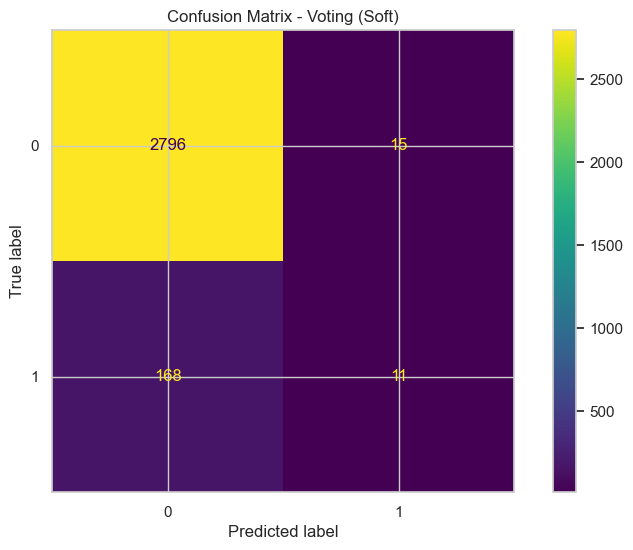

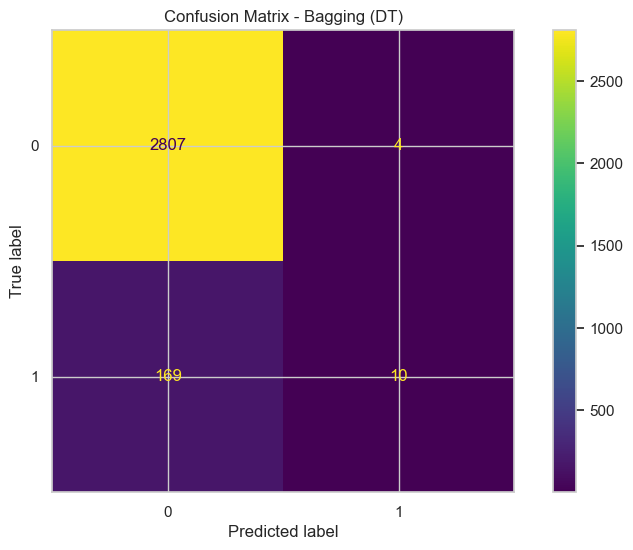

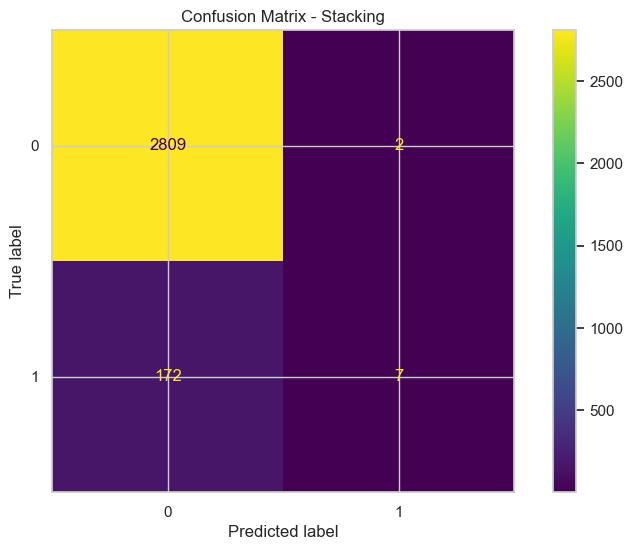

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

models_to_plot = {
    "Voting (Soft)": voting_soft,
    "Bagging (DT)": bagging_dt,
    "Stacking": stacking
}

for name, m in models_to_plot.items():
    y_pred = m.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


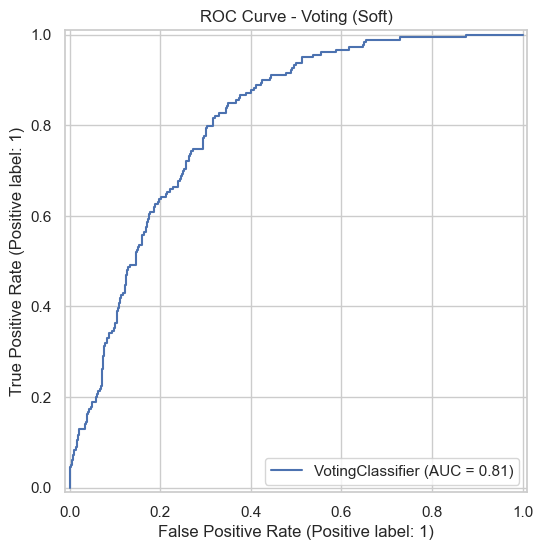

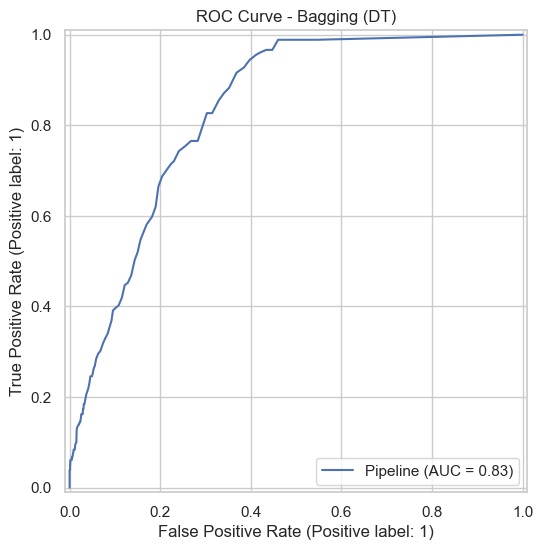

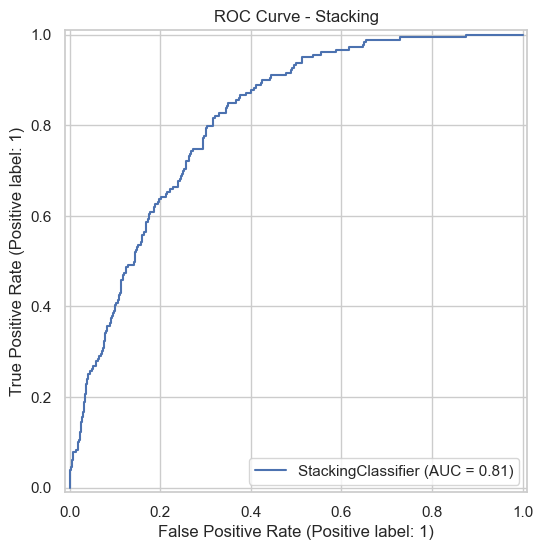

In [45]:
from sklearn.metrics import RocCurveDisplay

for name, m in models_to_plot.items():
    RocCurveDisplay.from_estimator(m, X_test, y_test)
    plt.title(f"ROC Curve - {name}")
    plt.show()


## Imbalance Handling Method 1: SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic
samples for the minority class to balance the dataset. This helps models
learn better decision boundaries for fraud detection.


In [46]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.tree import DecisionTreeClassifier

smote_dt = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=dt_pipe.named_steps["model"].max_depth,
        min_samples_split=dt_pipe.named_steps["model"].min_samples_split,
        min_samples_leaf=dt_pipe.named_steps["model"].min_samples_leaf
    ))
])

smote_dt.fit(X_train, y_train)

smote_results = evaluate_model(
    "Decision Tree + SMOTE",
    smote_dt,
    X_test,
    y_test
)

pd.DataFrame([smote_results])


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Decision Tree + SMOTE,0.894983,0.19457,0.240223,0.215,0.58845


### i did train the model (smote_dt) again because i wanted the output table apove to be visible so i did train it again in the next cell to show the logs inside MLFLOW UI

In [90]:
smote_dt_results = log_run("Decision Tree + SMOTE", smote_dt,
                           X_train, y_train, X_test, y_test,
                           stage="imbalance",
                           extra_params={"sampler": "SMOTE"})

2025/12/20 22:01:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


## Imbalance Handling Method 2: Class Weight

Cost-sensitive learning assigns higher penalty to misclassifying fraud cases.
This approach does not modify the data distribution, but instead adjusts
the learning objective of the model.


In [47]:
class_weight_dt = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=dt_pipe.named_steps["model"].max_depth,
        min_samples_split=dt_pipe.named_steps["model"].min_samples_split,
        min_samples_leaf=dt_pipe.named_steps["model"].min_samples_leaf
    ))
])

class_weight_dt.fit(X_train, y_train)

class_weight_results = evaluate_model(
    "Decision Tree + Class Weight",
    class_weight_dt,
    X_test,
    y_test
)

pd.DataFrame([class_weight_results])


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Decision Tree + Class Weight,0.899666,0.186528,0.201117,0.193548,0.572633


## Imbalance Handling Method 3: SMOTE + Tomek Links

This hybrid method combines oversampling with undersampling by removing
ambiguous samples near class boundaries. It aims to reduce noise while
balancing the dataset.


In [48]:
from imblearn.combine import SMOTETomek

smote_tomek_dt = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("smote_tomek", SMOTETomek(random_state=42)),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=dt_pipe.named_steps["model"].max_depth,
        min_samples_split=dt_pipe.named_steps["model"].min_samples_split,
        min_samples_leaf=dt_pipe.named_steps["model"].min_samples_leaf
    ))
])

smote_tomek_dt.fit(X_train, y_train)

smote_tomek_results = evaluate_model(
    "Decision Tree + SMOTE-Tomek",
    smote_tomek_dt,
    X_test,
    y_test
)

pd.DataFrame([smote_tomek_results])


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Decision Tree + SMOTE-Tomek,0.894983,0.19457,0.240223,0.215,0.58845


## Comparison: Imbalanced vs Balanced Training

We compare the baseline Decision Tree with different imbalance handling
techniques to evaluate improvements in fraud detection performance.


In [54]:
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_


In [55]:
imbalance_comparison = pd.DataFrame([
    evaluate_model("Decision Tree (Imbalanced)", best_dt, X_test, y_test),
    smote_results,
    class_weight_results,
    smote_tomek_results
]).sort_values(by="Recall", ascending=False)

imbalance_comparison


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Decision Tree + SMOTE,0.894983,0.194570,0.240223,0.215000,0.588450
3,Decision Tree + SMOTE-Tomek,0.894983,0.194570,0.240223,0.215000,0.588450
2,Decision Tree + Class Weight,0.899666,0.186528,0.201117,0.193548,0.572633
0,Decision Tree (Imbalanced),0.897659,0.174359,0.189944,0.181818,0.566335


In [61]:
import pandas as pd

viz_df = pd.DataFrame([
    # Baselines
    {"Model": "DT (Baseline)", "Recall": 0.189944, "F1": 0.181818, "ROC_AUC": 0.566335},
    {"Model": "KNN + FS", "Recall": 0.055866, "F1": 0.090498, "ROC_AUC": 0.706816},
    {"Model": "SVM (Baseline)", "Recall": 0.0, "F1": 0.0, "ROC_AUC": 0.798177},

    # Ensembles
    {"Model": "Voting (Soft)", "Recall": 0.061453, "F1": 0.107317, "ROC_AUC": 0.808013},
    {"Model": "Bagging (DT)", "Recall": 0.055866, "F1": 0.103627, "ROC_AUC": 0.832754},
    {"Model": "Stacking", "Recall": 0.039106, "F1": 0.074468, "ROC_AUC": 0.812707},

    # Imbalance handling
    {"Model": "DT + SMOTE", "Recall": 0.240223, "F1": 0.215000, "ROC_AUC": 0.588450},
    {"Model": "DT + Class Weight", "Recall": 0.201117, "F1": 0.193548, "ROC_AUC": 0.572633},
    {"Model": "DT + SMOTE-Tomek", "Recall": 0.240223, "F1": 0.215000, "ROC_AUC": 0.588450},
])


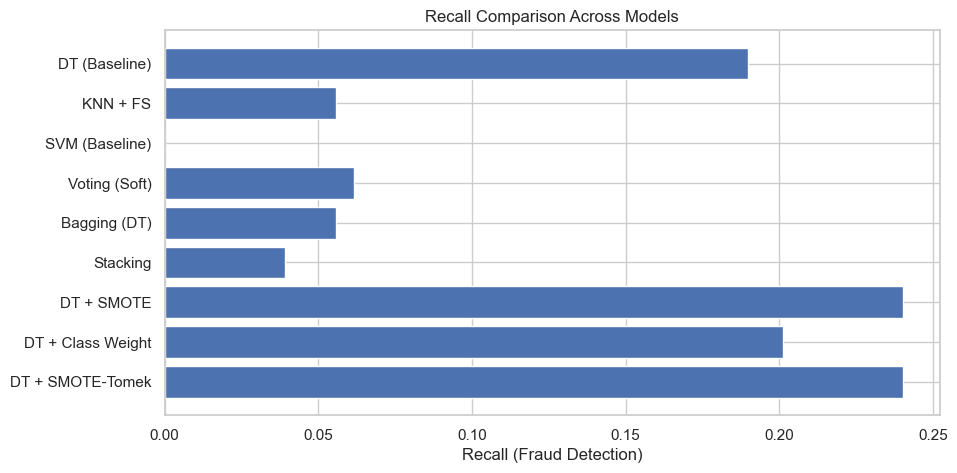

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.barh(viz_df["Model"], viz_df["Recall"])
plt.xlabel("Recall (Fraud Detection)")
plt.title("Recall Comparison Across Models")
plt.gca().invert_yaxis()
plt.show()


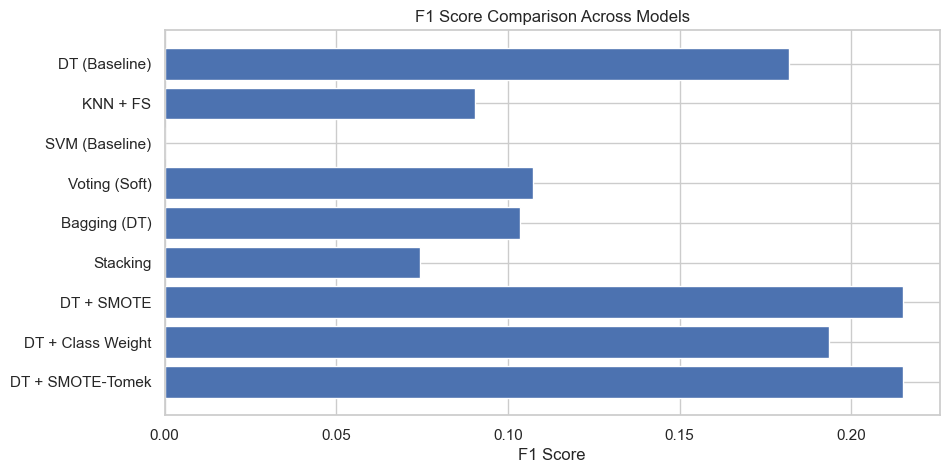

In [63]:
plt.figure(figsize=(10, 5))
plt.barh(viz_df["Model"], viz_df["F1"])
plt.xlabel("F1 Score")
plt.title("F1 Score Comparison Across Models")
plt.gca().invert_yaxis()
plt.show()


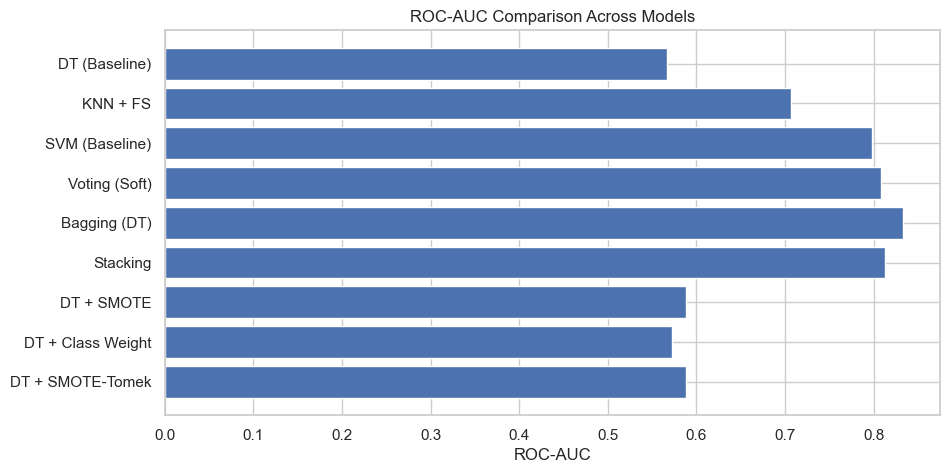

In [64]:
plt.figure(figsize=(10, 5))
plt.barh(viz_df["Model"], viz_df["ROC_AUC"])
plt.xlabel("ROC-AUC")
plt.title("ROC-AUC Comparison Across Models")
plt.gca().invert_yaxis()
plt.show()


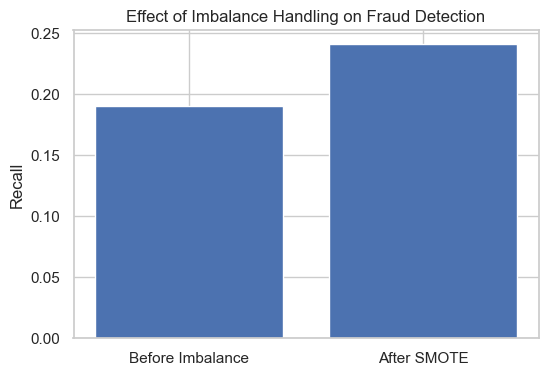

In [65]:
before_after = pd.DataFrame({
    "Stage": ["Before Imbalance", "After SMOTE"],
    "Recall": [0.189944, 0.240223]
})

plt.figure(figsize=(6, 4))
plt.bar(before_after["Stage"], before_after["Recall"])
plt.ylabel("Recall")
plt.title("Effect of Imbalance Handling on Fraud Detection")
plt.show()


## Confusion Matrices: Effect of Imbalance Handling

Confusion matrices are used to compare how imbalance handling techniques
affect fraud detection performance, particularly the recall of the minority class.


In [58]:
# Use the already-fitted tuned decision tree pipeline
# (this is the one you evaluated successfully before)
dt_imbalanced = best_dt   # NOT dt_pipe

# If best_dt is not defined in your notebook, then run the tuning cell again
# or uncomment the next line to fit dt_pipe directly:
# dt_imbalanced = dt_pipe.fit(X_train, y_train)


In [ ]:
# Refit the imbalance-handling models 
smote_dt.fit(X_train, y_train)
class_weight_dt.fit(X_train, y_train)
smote_tomek_dt.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Year',
                                                   'DriverRating',
                                                   'WeekOfMonth',
                                                   'WeekOfMonthClaimed']),
                                                 ('nom',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Month', 'DayOfWeek',
                                                   'MonthClaimed',
                                                   'DayOfWeekClaimed', 'Make',
                                                   'AccidentArea', 'Sex',
                                                   'MaritalSta...
                                                                                               '8',
                                                                                               'more '
                                                                                               'than '
                                                                                               '8']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['VehiclePrice',
                                                   'Days:Policy-Accident',
                                                   'Days:Policy-Claim',
                                                   'PastNumberOfClaims',
                                                   'AgeOfVehicle',
                                                   'AgeOfPolicyHolder',
                                                   'NumberOfSuppliments',
                                                   'AddressChange-Claim',
                                                   'NumberOfCars'])])),
                ('smote_tomek', SMOTETomek(random_state=42)),
                ('model', DecisionTreeClassifier(random_state=42))])

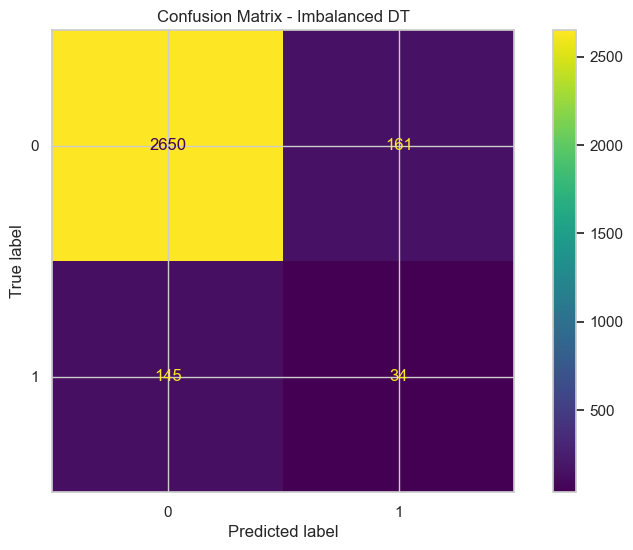

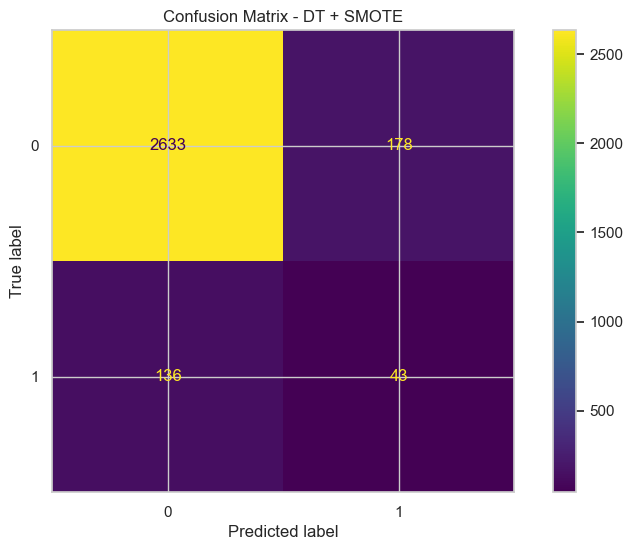

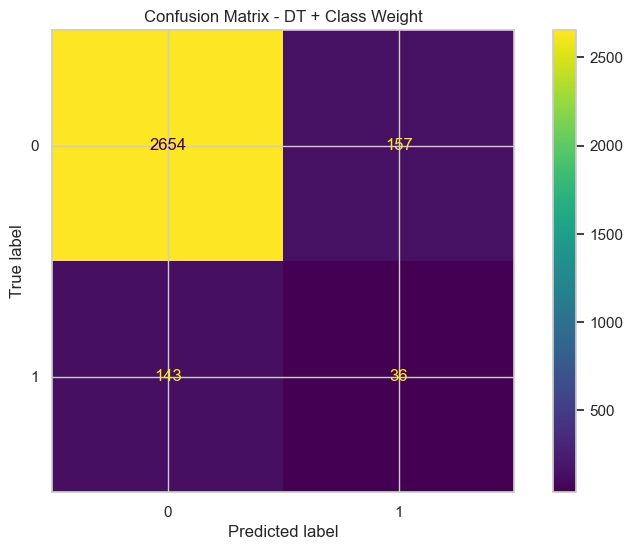

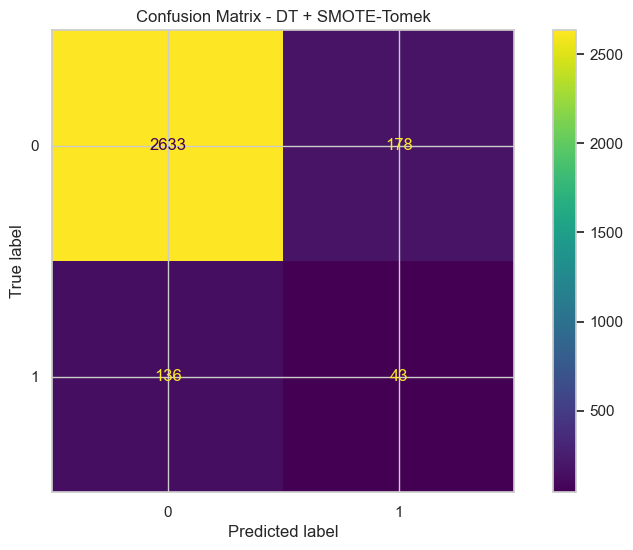

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models_cm = {
    "Imbalanced DT": dt_imbalanced,
    "DT + SMOTE": smote_dt,
    "DT + Class Weight": class_weight_dt,
    "DT + SMOTE-Tomek": smote_tomek_dt
}

for name, model in models_cm.items():
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
